## 3. Modeling TF-IDF x BILSTM

### 3.1 Importing the Libraries 

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import ( Dense, Embedding, Bidirectional, LSTM, Input, Concatenate, Dropout)

2025-11-17 10:27:29.453256: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 10:27:29.453493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 10:27:29.484953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 10:27:30.293677: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
MODEL_SAVE_PATH = "../models/bilstm_model.keras"

### 3.2 Define the Parameter

In [3]:
VOCAB_SIZE = 5000
TFIDF_FEATURES = 5000
MAX_LEN = 200

### 3.2 Load the Dataset

In [4]:
X_train_pad   = pickle.load(open("../dataset/processed/02_after_FE/X_train_pad.pkl", "rb"))
X_train_tfidf = pickle.load(open("../dataset/processed/02_after_FE/X_train_tfidf.pkl", "rb"))
y_train       = pickle.load(open("../dataset/processed/02_after_FE/y_train.pkl", "rb"))

X_test_pad    = pickle.load(open("../dataset/processed/02_after_FE/X_test_pad.pkl", "rb"))
X_test_tfidf  = pickle.load(open("../dataset/processed/02_after_FE/X_test_tfidf.pkl", "rb"))
y_test        = pickle.load(open("../dataset/processed/02_after_FE/y_test.pkl", "rb"))

### 3.3 Check Array Dimension

In [5]:
print(f"Shape X_train_pad: {X_train_pad.shape}")
print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")

Shape X_train_pad: (16479, 200)
Shape X_train_tfidf: (30432, 5000)
Shape y_train: (30432,)
Shape y_test: (4120,)


### 3.4 Build BiLSTM Model with TF-IDF

In [6]:
# squence for bilstm
input_seq = Input(shape=(MAX_LEN,), name='input_sequence')
x = Embedding(input_dim=VOCAB_SIZE, output_dim=128)(input_seq) 

x = Bidirectional(LSTM(32))(x)

x = Dropout(0.5)(x) 

# vektor TF-IDF
input_tfidf = Input(shape=(TFIDF_FEATURES,), name='input_tfidf') 
y = Dense(16, activation='relu')(input_tfidf) 

# concate
combined = Concatenate()([x, y])

# output layer
z = Dense(32, activation="relu")(combined)
z = Dropout(0.5)(z) 
output_layer = Dense(1, activation="sigmoid")(z)

# define model
model = Model(inputs=[input_seq, input_tfidf], outputs=output_layer)

optimizer = Adam(learning_rate=0.0001)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer, 
    metrics=['accuracy']
)
print(model.summary())

E0000 00:00:1763350051.984130   69452 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763350051.997144   69452 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │    640,000 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     41,216 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_tfidf         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     80,016 │ input_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 763,857 (2.91 MB)

 Trainable params: 763,857 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

None


### 3.5 Define Callbacks

In [7]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

### 3.6 Training

In [8]:
history = model.fit(
    [X_train_pad, X_train_tfidf],
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9002 - loss: 0.4539 - val_accuracy: 0.9220 - val_loss: 0.1756
Epoch 2/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9409 - loss: 0.1380 - val_accuracy: 0.9624 - val_loss: 0.0890
Epoch 3/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9749 - loss: 0.0798 - val_accuracy: 0.9830 - val_loss: 0.0629
Epoch 4/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.9899 - loss: 0.0510 - val_accuracy: 0.9845 - val_loss: 0.0486
Epoch 5/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9930 - loss: 0.0343 - val_accuracy: 0.9851 - val_loss: 0.0449
Epoch 6/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9955 - loss: 0.0241 - val_accuracy: 0.9860 - val_loss: 0.0517
Epoch 7/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9970 - loss: 0.0176 - val_accuracy: 0.9857 - val_loss: 0.0514
Epoch 8/50
206/206 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9981 - loss: 0.0128 - val_acc

### 3.7 Evaluation

In [9]:
loss, acc = model.evaluate([X_test_pad, X_test_tfidf], y_test, verbose=1)
print(f"\nAkurasi Test (BiLSTM + TF-IDF): {acc:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9835 - loss: 0.0579

Akurasi Test (BiLSTM + TF-IDF): 0.9835


Membuat plot training & validation loss...


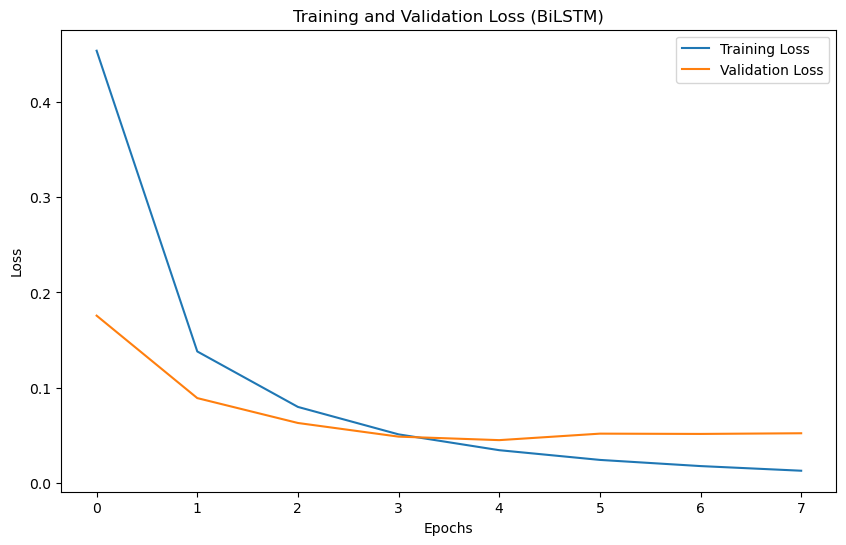

In [10]:
print("Membuat plot training & validation loss...")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (BiLSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 3.8 Save Model

In [11]:
os.makedirs("models", exist_ok=True)
model.save(MODEL_SAVE_PATH)
print("Model saved to:", MODEL_SAVE_PATH)

Model saved to: ../models/bilstm_model.keras
